<a href="https://colab.research.google.com/github/Sonic815/Machine-Learning/blob/main/LAB2_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A1

In [ ]:
import numpy as np
from numpy.linalg import matrix_rank
import pandas as pd
import time
import matplotlib.pyplot as plt

df = pd.read_excel('Lab Session Data.xlsx', sheet_name = 'Purchase data',usecols="A:E")
X = df.iloc[:,1:4]
Y = df.iloc[:,4]
print(X)
print(Y)
print(X.shape)
print(Y.shape)
print(X.shape[0])
print(Y.shape[0])
matrix_rank(X)
matrix_rank(Y)
X_inv = np.linalg.pinv(X)
w = X_inv @ Y
print(w)

   Candies (#)  Mangoes (Kg)  Milk Packets (#)
0           20             6                 2
1           16             3                 6
2           27             6                 2
3           19             1                 2
4           24             4                 2
5           22             1                 5
6           15             4                 2
7           18             4                 2
8           21             1                 4
9           16             2                 4
0    386
1    289
2    393
3    110
4    280
5    167
6    271
7    274
8    148
9    198
Name: Payment (Rs), dtype: int64
(10, 3)
(10,)
10
10
[ 1. 55. 18.]


A2

In [ ]:
df["Class"] = df["Payment (Rs)"].apply(lambda x : "RICH" if x>=200 else "POOR")

print(df)

  Customer  Candies (#)  Mangoes (Kg)  Milk Packets (#)  Payment (Rs) Class
0      C_1           20             6                 2           386  RICH
1      C_2           16             3                 6           289  RICH
2      C_3           27             6                 2           393  RICH
3      C_4           19             1                 2           110  POOR
4      C_5           24             4                 2           280  RICH
5      C_6           22             1                 5           167  POOR
6      C_7           15             4                 2           271  RICH
7      C_8           18             4                 2           274  RICH
8      C_9           21             1                 4           148  POOR
9     C_10           16             2                 4           198  POOR


A3

Dataset:
             Date Month  Day    Price     Open     High      Low   Volume  \
0    Jun 29, 2021   Jun  Tue  2081.85  2092.00  2126.90  2065.05    1.67M   
1    Jun 28, 2021   Jun  Mon  2077.75  2084.00  2112.45  2068.40  707.73K   
2    Jun 25, 2021   Jun  Fri  2068.85  2084.35  2088.50  2053.10  475.82K   
3    Jun 24, 2021   Jun  Thu  2072.95  2098.00  2098.00  2066.00  541.51K   
4    Jun 23, 2021   Jun  Wed  2078.25  2102.00  2111.40  2072.00  809.62K   
..            ...   ...  ...      ...      ...      ...      ...      ...   
244  Jul 07, 2020   Jul  Tue  1397.40  1410.00  1411.00  1390.05  480.21K   
245  Jul 06, 2020   Jul  Mon  1400.75  1405.50  1415.50  1394.00  614.93K   
246  Jul 03, 2020   Jul  Fri  1405.10  1415.00  1425.00  1398.00  599.49K   
247  Jul 02, 2020   Jul  Thu  1412.35  1440.00  1467.80  1395.30    2.16M   
248  Jul 01, 2020   Jul  Wed  1363.05  1363.65  1377.00  1356.00  383.00K   

       Chg%  status  
0    0.0020  PROFIT  
1    0.0043  PROFIT  


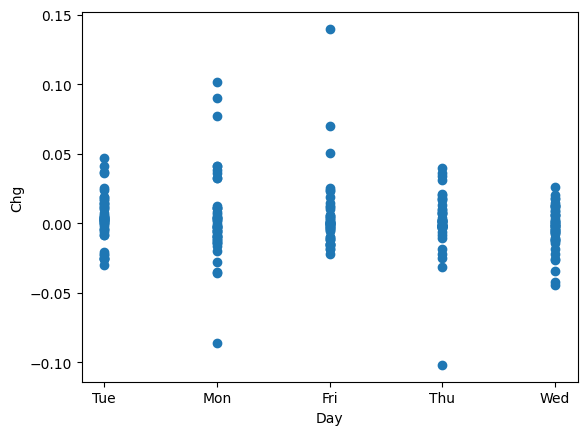

In [ ]:
di = pd.read_excel('Lab Session Data.xlsx',sheet_name = 'IRCTC Stock Price',usecols="A:I")
X2 = di.iloc[:,1:8]
Y2 = di.iloc[:,8]
xmean = di["Price"].mean()
xvar = di["Price"].var()
def com_mean(data):
  cost =0
  for i in data:
    cost += i
  avg = cost/len(data)
  return avg

def com_var(data):
  var = 0
  for i in data:
    var += (i-di["Price"].mean())**2
  var = var/len(data)
  return var
xmeancom = com_mean(di["Price"])
xvarcom = com_var(di["Price"])

def exec_time(fun,arg):
  times =[]
  for i in range(10):
    start = time.perf_counter()
    fun(arg)
    end = time.perf_counter()
    times.append(end-start)
  return sum(times)/len(times)

meane = exec_time(com_mean,di["Price"])
meanv = exec_time(com_var,di["Price"])

wednesday = di[di["Day"]=="Wed"]
mean_wed = np.mean(wednesday["Price"])

april = di[di["Month"]=="Apr"]
mean_apr = np.mean(april["Price"])

di["status"] = di["Chg%"].apply(lambda x: "PROFIT" if x>0 else "LOSS")

loss_count = np.sum(di["status"]=="LOSS")
prob_loss = loss_count/len(di["status"])

profit_count_wed = np.sum((di["status"]=="PROFIT") & (di["Day"]=="Wed"))
prob_prof_wed = profit_count_wed/len(di["status"])

total_wed = np.sum(di["Day"]=="Wed")

cond_prob = profit_count_wed/total_wed

plt.scatter(di["Day"],di["Chg%"])
plt.xlabel("Day")
plt.ylabel("Chg")

print("Dataset:")
print(di)

print("Mean using package :", xmean)
print("Variance using package :", xvar)

print("Mean using custom function :", xmeancom)
print("Variance using custom function :", xvarcom)

print("Average execution time of custom mean :", meane, "seconds")
print("Average execution time of custom variance :", meanv, "seconds")

print("\nWednesday Data:")
print(wednesday)

print("\nWednesday Sample Mean :", mean_wed)
print("Population Mean :", xmean)

if mean_wed > xmean:
    print("Observation : Wednesday mean is greater than the population mean.")
elif mean_wed < xmean:
    print("Observation : Wednesday mean is smaller than the population mean.")
else:
    print("Observation : Both means are equal.")

print("\nApril Data:")
print(april)

print("\nApril Sample Mean :", mean_apr)
print("Population Mean :", xmean)

if mean_apr > xmean:
    print("Observation : April mean is greater than the population mean.")
elif mean_apr < xmean:
    print("Observation : April mean is smaller than the population mean.")
else:
    print("Observation : Both means are equal.")

print("\nProfit/Loss Status:")
print(di["status"])

print("\nNumber of Loss Days :", loss_count)
print("Probability of Loss :", prob_loss)

print("\nProfit Wednesdays :", profit_count_wed)
print("Probability of Profit on Wednesday :", prob_prof_wed)

print("\nTotal Wednesdays :", total_wed)
print("Conditional Probability P(Profit | Wednesday) :", cond_prob)

A4

In [ ]:
dt = pd.read_excel("Lab Session Data.xlsx",sheet_name ='thyroid0387_UCI',usecols="A:AE")
X3 = dt.iloc[:,1:-1]
Y3 = dt.iloc[:,-1]
print(dt.dtypes)
for col in dt.columns:
    if dt[col].dtype == "object":
        print("\nColumn:", col)
        print(dt[col].unique())

for col in dt.select_dtypes(include=["int64","float64"]).columns:
  print("min",dt[col].min())
  print("max",dt[col].max())
  print("range is",dt[col].max()-dt[col].min())
print(df.isnull().sum())

for col in dt.select_dtypes(include=["int64","float64"]).columns:
  Q1 = dt[col].quantile(0.25)
  Q3 = dt[col].quantile(0.75)
  IQR = Q3-Q1

  low_limit = Q1 - 1.5*IQR
  upp_limit = Q3 + 1.5*IQR
  outlier = dt[(dt[col]<low_limit)|(dt[col]>upp_limit)]
print(outlier)

Record ID                     int64
age                           int64
sex                          object
on thyroxine                 object
query on thyroxine           object
on antithyroid medication    object
sick                         object
pregnant                     object
thyroid surgery              object
I131 treatment               object
query hypothyroid            object
query hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object
hypopituitary                object
psych                        object
TSH measured                 object
TSH                          object
T3 measured                  object
T3                           object
TT4 measured                 object
TT4                          object
T4U measured                 object
T4U                          object
FTI measured                 object
FTI                          object
TBG measured                